# 🏥 Medical Insurance Cost Prediction
### End-to-End Machine Learning Pipeline

**Goal:** Predict individual medical insurance charges using demographic and lifestyle features.

**Dataset:** [Kaggle — Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance)

**Pipeline:**
1. Load & Explore Data (EDA)
2. Preprocessing & Feature Engineering
3. Model Training & Cross-Validation
4. Model Evaluation
5. Prediction on New Data

In [182]:
from PIL.IcnsImagePlugin import read_32
from sklearn.linear_model import LinearRegression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score,r2_score
from sklearn.preprocessing import LabelEncoder


## Load Data

In [183]:
data=pd.read_csv('/Users/rudra/PycharmProjects/medical-insurance-cost-prediction/data/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Analysis

In [184]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [185]:
data.shape

(1338, 7)

In [186]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [187]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: xlabel='age', ylabel='Count'>

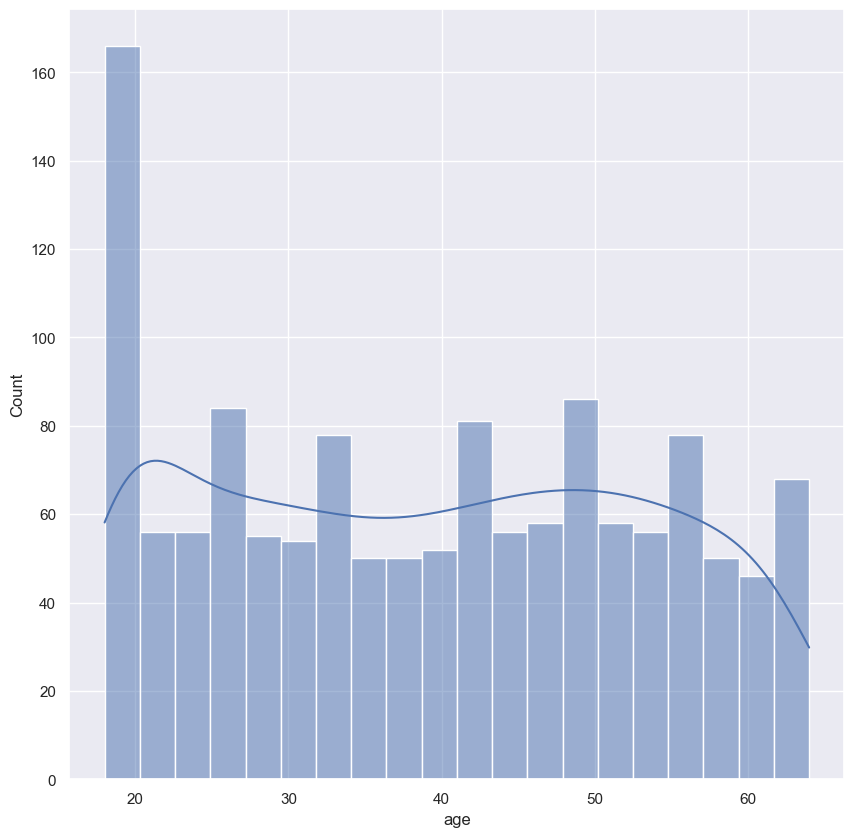

In [188]:
sns.set()
plt.figure(figsize=(10,10))
sns.histplot(data['age'],bins=20,kde=True)


<Axes: xlabel='sex', ylabel='count'>

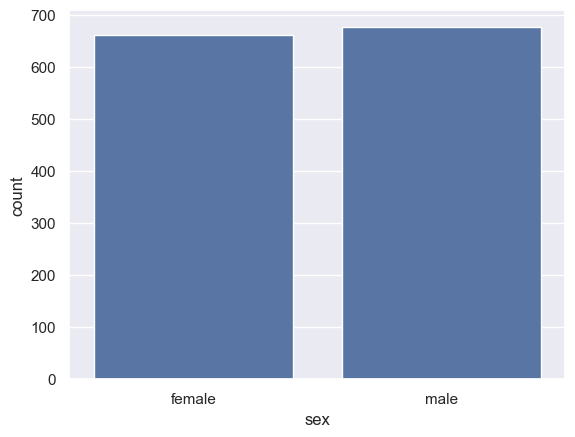

In [189]:

sns.countplot(x='sex', data=data)

normal bmi-18 to 25

([<matplotlib.axis.XTick at 0x13f835090>,
 [Text(10.0, 0, 'Underweight'),
  Text(22.5, 0, 'Fit'),
  Text(32.5, 0, 'Overweight')])

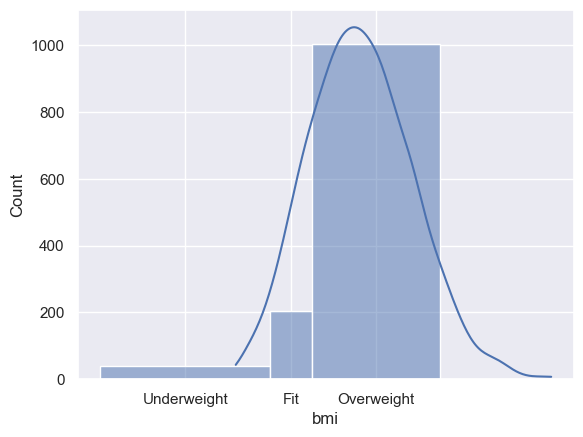

In [190]:
sns.histplot(data['bmi'],bins=[0,20,25,40],kde=True)
plt.xticks([10, 22.5, 32.5], ['Underweight', 'Fit', 'Overweight'])

many lies in overweight


<Axes: xlabel='children', ylabel='count'>

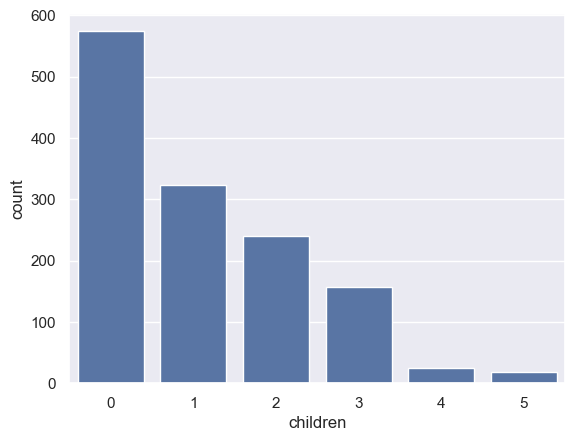

In [191]:
sns.countplot(x='children', data=data)

<Axes: xlabel='smoker', ylabel='count'>

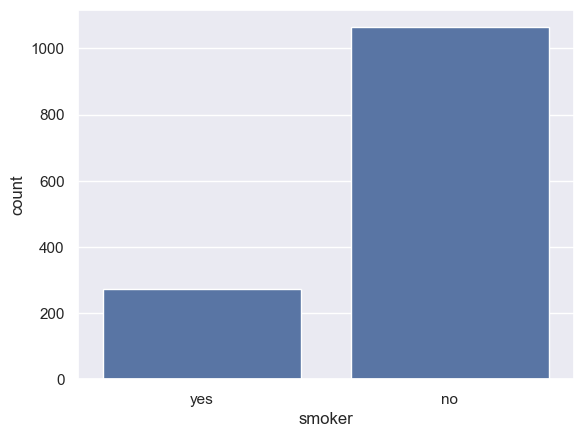

In [192]:
sns.countplot(x='smoker',data=data)

<Axes: xlabel='region', ylabel='count'>

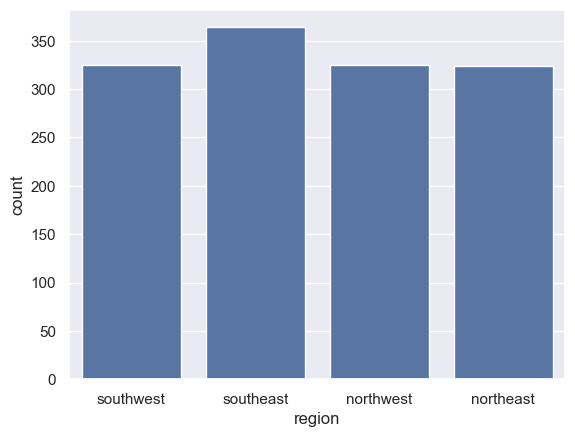

In [193]:
sns.countplot(x='region', data=data)

In [194]:
data['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


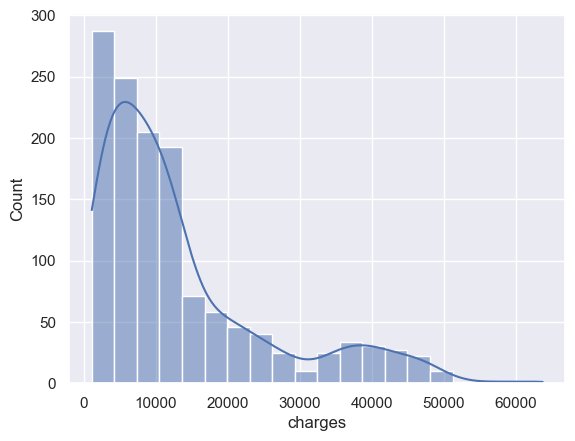

In [195]:
sns.histplot(data['charges'],bins=20,kde=True)
data.head()

## Data Preprocessing

In [196]:
le=LabelEncoder()
print(data.head())
data['sex']=le.fit_transform(data['sex'])
data['smoker']=le.fit_transform(data['smoker'])
data['region']=le.fit_transform(data['region'])

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


0->female

1->male

0->non smoker

1->smoker

3->southwest,2->southeast,1-northwest,0-northeast



In [197]:
data[['smoker','region','sex']]

,smoker,region,sex
0,1,3,0
1,0,2,1
2,0,2,1
3,0,1,1
4,0,1,1
...,...,...,...
1333,0,1,1
1334,0,0,0
1335,0,2,0
1336,0,3,0


## Spliiting the Data


In [198]:
X=data.drop('charges',axis=1)
Y=data['charges']
print(X,Y)

      age  sex     bmi  children  smoker  region
0      19    0  27.900         0       1       3
1      18    1  33.770         1       0       2
2      28    1  33.000         3       0       2
3      33    1  22.705         0       0       1
4      32    1  28.880         0       0       1
...   ...  ...     ...       ...     ...     ...
1333   50    1  30.970         3       0       1
1334   18    0  31.920         0       0       0
1335   18    0  36.850         0       0       2
1336   21    0  25.800         0       0       3
1337   61    0  29.070         0       1       1

[1338 rows x 6 columns] 0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


## Training and testing Data


In [199]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
X_train.shape

(1070, 6)

## Model training

In [201]:
model=LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [206]:
training_data_prediction=model.predict(X_train)
score=r2_score(Y_train,training_data_prediction)
score

0.7417049283233981

In [207]:
test_data_prediction=model.predict(X_test)
score=r2_score(Y_test,test_data_prediction)
score

0.7833463107364538

## checking data

In [212]:
input_data=(46,0,33.44,1,0,2)
arr=np.asarray(input_data)
reshaped_arr=arr.reshape(1,-1)
predicted=model.predict(reshaped_arr)
print("predicted value",predicted[0])

predicted value 10989.03754316403


/opt/anaconda3/envs/medical-insurance-cost-prediction/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
